# Choosing a control chart

This tutorial matches your data to the right control chart. mfgQC infers a
variables chart from your subgroup size, but it never guesses for attribute
(count) data, and it never silently switches a chart you asked for. The rules
below are exactly what the code does, and every cell runs, so open it and try
your own numbers.

<div class="nb-buttons"><a class="nb-btn" target="_blank" href="https://colab.research.google.com/github/cjbrant/mfgQC/blob/main/docs/guide/choosing-a-control-chart.ipynb">Run in Colab</a><a class="nb-btn" target="_blank" href="https://github.com/cjbrant/mfgQC/blob/main/docs/guide/choosing-a-control-chart.ipynb">View on GitHub</a><a class="nb-btn" target="_blank" href="https://raw.githubusercontent.com/cjbrant/mfgQC/main/docs/guide/choosing-a-control-chart.ipynb" download>Download notebook</a></div>

Install it first (skip this if mfgQC is already in your environment):

In [ ]:
!pip install mfgqc

## 1. How mfgQC picks a chart when you don't

Call `control_chart()` with no `kind=` and mfgQC chooses a variables chart from
the subgroup sizes in your `QCData`. The rule is purely a function of subgroup
size:

| Subgroup size | Inferred chart | `kind` recorded |
| --- | --- | --- |
| every subgroup is size 1 | Individuals + Moving Range | `i_mr` |
| 2 to 10 inclusive | X-bar and R | `xbar_r` |
| greater than 10 | X-bar and S | `xbar_s` |

The boundary is inclusive at 10. A subgroup size of 10 infers X-bar and R, and
11 infers X-bar and S. The reasoning is statistical. The range is an efficient
spread estimator for small subgroups but loses efficiency as the subgroup
grows, so the sample standard deviation takes over once subgroups get large.

Here is a made-up run of 100 widths in 20 subgroups of 5. With five readings
per subgroup, the rule infers an X-bar and R chart.

In [2]:
import numpy as np, pandas as pd, mfgqc

rng = np.random.default_rng(7)
df = pd.DataFrame({
    "width": np.round(rng.normal(1.50, 0.11, 100), 3),
    "lot":   np.repeat(np.arange(1, 21), 5),
})

qc = mfgqc.load(df, measure="width", subgroup="lot", subgroup_size=5)

print(qc.control_chart())     # no kind= -> inferred from subgroup size

Control Chart: xbar_r (inferred); rules=nelson
Xbar: CL=1.4809  UCL=1.6169  LCL=1.345
R: CL=0.2356  UCL=0.49806  LCL=0

Out-of-control signals: none (process in control)

Assumption checks:
  [PASS] independence (lag-1 autocorrelation): r=0.193, p=0.388; n=20 [low power]


The title reads `xbar_r (inferred)`. The `(inferred)` tag is recorded in the
result and in provenance, so an audit can always see that mfgQC picked the
chart rather than you. Inference requires a constant subgroup size. If sizes
vary, the X-bar charts raise rather than average over ragged groups (the
individuals path is the exception).

Every result draws its own chart. Make the chart the last expression of a cell
to display it.

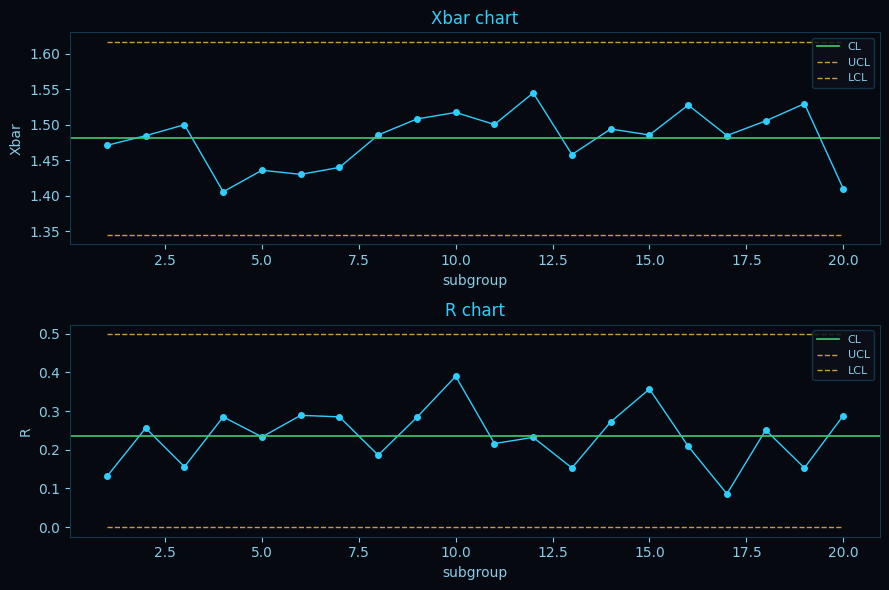

In [3]:
qc.control_chart().view()

## 2. Overriding the inference with `kind=`

Pass `kind=` to force a specific chart. The complete set of valid strings is:

| `kind=` | Chart |
| --- | --- |
| `"i_mr"` (alias `"i"`) | Individuals + Moving Range |
| `"xbar_r"` | X-bar and R |
| `"xbar_s"` | X-bar and S |
| `"p"` | proportion defective |
| `"np"` | number defective |
| `"c"` | count of defects |
| `"u"` | defects per unit |

Any other value raises `ValueError`. The override is honored exactly. mfgQC
will not swap an explicitly requested kind for a different one. When you
specify a kind the title reads `(specified)` instead of `(inferred)`.

Even with subgrouped continuous data you may want individuals, for example
when you do not trust the subgrouping. Pass `kind="i_mr"` on a plain measure
column and each row is treated as its own size-1 subgroup.

In [4]:
rng = np.random.default_rng(3)
ind = pd.DataFrame({"thickness": np.round(rng.normal(12.0, 0.4, size=30), 3)})
qc_ind = mfgqc.load(ind, measure="thickness")

print(qc_ind.control_chart(kind="i_mr"))

Control Chart: i_mr (specified); rules=nelson
Individual: CL=12.023  UCL=13.35  LCL=10.697
MR: CL=0.49872  UCL=1.6293  LCL=0

Out-of-control signals: 2
  point 2 (dispersion): nelson_1 - one point beyond control limits
  point 10 (dispersion): nelson_1 - one point beyond control limits

Assumption checks:
  [PASS] independence (lag-1 autocorrelation): r=-0.144, p=0.43; n=30


The title reads `i_mr (specified)`. The moving-range (dispersion) panel is
checked independently, so a point whose moving range blows up is flagged even
when the individual value stays inside its own limits.

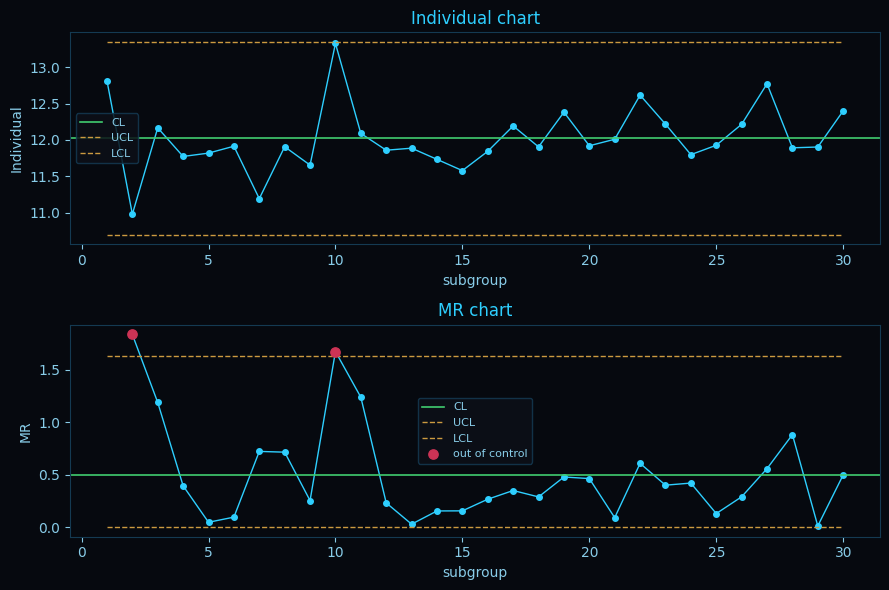

In [5]:
qc_ind.control_chart(kind="i_mr").view()

## 3. Attribute charts are always explicit

The `p`, `np`, `c`, and `u` charts are only ever produced when you ask for
them by name. mfgQC infers variables charts from subgroup size, but it cannot
tell from the numbers alone whether a column of integers is a measurement
(variables) or a count of defectives or defects (attribute). The value `7`
could be a thickness reading or seven rejects. The choice of attribute family
also encodes a model assumption (binomial for p and np, Poisson for c and u)
that only you know. So mfgQC requires you to declare it.

A p-chart for fraction defective names the defective-count column as the
`measure` and passes the inspected sample size with `n=`. For p, np
(constant-n only), and u you supply the sample size via `n=`: a column name
for per-point sizes (giving stepped limits when they vary), a constant int, or
`None` to fall back to a `size` role.

In [6]:
defects = pd.DataFrame({
    "defectives": [3, 5, 2, 4, 6, 1, 3, 5, 8, 2, 4, 3, 7, 2, 5],
    "inspected":  [100] * 15,
})
qc_p = mfgqc.load(defects, measure="defectives")

print(qc_p.control_chart(kind="p", n="inspected"))

Control Chart: p (specified); rules=nelson
Proportion (p): CL=0.04  UCL=0.098788  LCL=0

Out-of-control signals: none (process in control)

Assumption checks:
  [PASS] dispersion (chi-square dispersion): dispersion ratio 1.04, p=0.407; n=15 [low power]


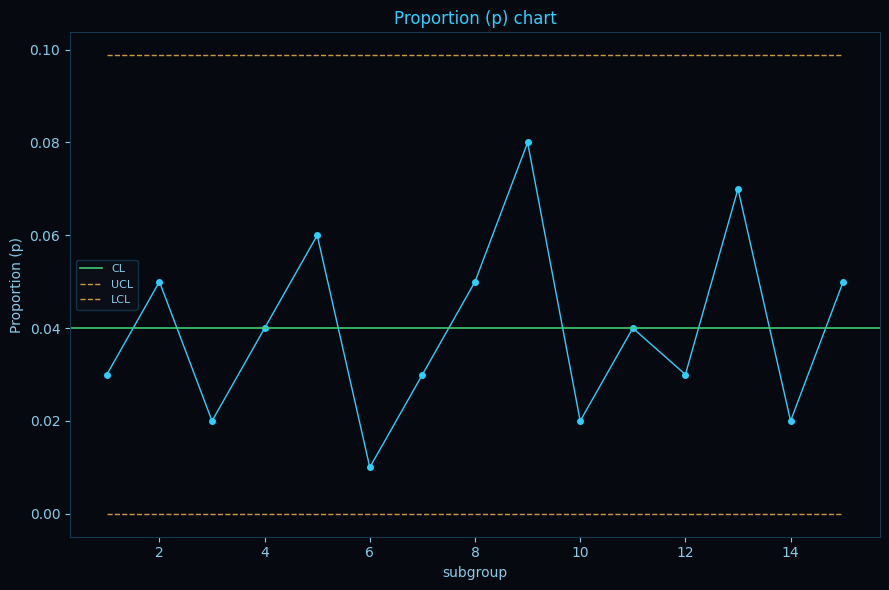

In [7]:
qc_p.control_chart(kind="p", n="inspected").view()

A c-chart for total defects per inspection unit needs no `n=`, because the
area of opportunity is constant.

In [8]:
cdf = pd.DataFrame({"flaws": [7, 3, 5, 9, 4, 6, 2, 8, 5, 14, 3, 6, 4, 5, 7]})
qc_c = mfgqc.load(cdf, measure="flaws")

print(qc_c.control_chart(kind="c"))

Control Chart: c (specified); rules=nelson
Count (c): CL=5.8667  UCL=13.133  LCL=0

Out-of-control signals: 1
  point 10 (location): nelson_1 - one point beyond 3 sigma

Assumption checks:
  [PASS] dispersion (chi-square dispersion): dispersion ratio 1.51, p=0.0993; n=15 [low power]


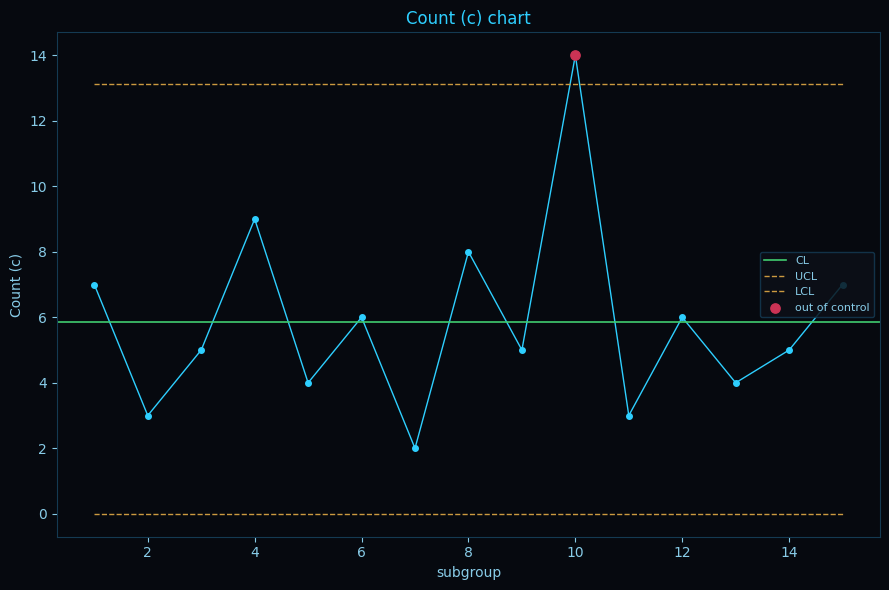

In [9]:
qc_c.control_chart(kind="c").view()

## 4. Small sustained shifts: EWMA and CUSUM

A Shewhart chart reacts only to the current point. When a process drifts by a
small, sustained amount, a Shewhart chart can be slow to catch it. EWMA and
CUSUM accumulate evidence across points and detect a small drift faster.

These are not `kind=` values of `control_chart()`. They are separate methods,
`ewma_chart` and `cusum_chart`, because they take their own parameters: the
smoothing weight `lam` and limit width `L` for EWMA, the reference value `k`
and decision interval `h` for CUSUM.

In [10]:
print(qc.ewma_chart(lam=0.1, L=2.7))

EWMA Chart: lambda=0.1, L=2.7
EWMA: CL=1.4809  mu0=1.4809  sigma=0.098646
UCL: 1.5076 -> 1.542 (time-varying)
LCL: 1.4543 -> 1.4198 (time-varying)

Out-of-control signals: none (process in control)

Assumption checks:
  [PASS] in_control_parameters (phase-I baseline (assumed)): phase-I baseline (assumed); n=100

Recommendations:
  - EWMA/CUSUM assume the in-control mu0 and sigma are known from a stable phase-I baseline; here mu0=1.4809 (sample mean) and sigma=0.098646 (MR-bar/d2 (d2=1.128)). Validate phase-I stability (e.g. an I-MR chart) before trusting these limits.


In [11]:
print(qc.cusum_chart(k=0.5, h=5))

CUSUM Chart: k=0.5, h=5
CUSUM: mu0=1.4809  sigma=0.098646
K (reference)=0.049323  H (decision interval)=0.49323

Out-of-control signals: none (process in control)

Assumption checks:
  [PASS] in_control_parameters (phase-I baseline (assumed)): phase-I baseline (assumed); n=100

Recommendations:
  - EWMA/CUSUM assume the in-control mu0 and sigma are known from a stable phase-I baseline; here mu0=1.4809 (sample mean) and sigma=0.098646 (MR-bar/d2 (d2=1.128)). Validate phase-I stability (e.g. an I-MR chart) before trusting these limits.


The standardized short-run chart, `short_run_chart`, plots many part numbers
on one chart and is likewise its own method rather than a `kind=` value.

## 5. What every chart checks for you

Beyond drawing limits, each chart does two things.

- It reports run-rule violations. The default ruleset is `rules="nelson"`
  (pass `rules="western_electric"` for the WE zone tests). Each signal lists
  the point, the panel (location or dispersion), and the rule that fired.
  Signals are reported, never auto-removed.
- It checks independence. Variables charts run a lag-1 autocorrelation test and
  attach the result as an assumption check. Control-chart limits assume
  successive points are independent. If they are autocorrelated, the limits are
  too tight and you will see false alarms. mfgQC tells you. It does not
  silently widen the limits.

A capability index ($C_p$, $C_{pk}$, $P_{pk}$) only means something for a
process that is in statistical control. Establish stability with the control
chart first, then compute capability on the same data.

## Next

- [Control charts reference](/reference/control-charts/) gives the limit
  formulas, constants, and source standards behind every chart.
- [Run rules reference](/reference/run-rules/) lists the full Nelson and
  Western Electric rule sets and what each one means.
- [Advanced charts reference](/reference/advanced-charts/) covers EWMA, CUSUM,
  and the standardized short-run chart in detail.